Test if the properties of the 2-timescale noise are preserved if time stepping is large (1 year). If not, test if averaging the noise up to 1 year preserves the properties.

Properties to test:
- Variance of the noise should be close to the specified variance.
- Spectral density should match between both time stepping methods.

If the properties are not preserved, average the noise up to 1 year and check:
- Same properties as above.
- Firn-smoothed noise should be the same between the averaged noise and the 0.1-year time-stepped noise.

Compare:
Time stepping of 1/24 years vs 1 year

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

from methane_noise_forcing.noise import simulate_two_timescale_ar1, calculate_two_timescale_ar1_params
from methane_noise_forcing.core import FirnFilter

## simulate noise

In [2]:
# parameters of the noise
tau_ch4 = 10.0
tau_forcing = 0.1
variance_ch4 = 200.0  # ppb^2
dt_small = 1 / 24  # time step [years]
dt_large = 1  # time step [years]
years = 1000  # length of each simulation [years], 400 years spinup
n_ens = 10  # number of ensemble members
N_small = int(years / dt_small)
N_large = int(years / dt_large)

In [3]:
# simulate the two timescale AR(1) process
ch4_small_ens, forcing_small_ens = simulate_two_timescale_ar1(
    tau_x=tau_ch4,
    tau_eta=tau_forcing,
    variance_x=variance_ch4,
    dt=dt_small,
    n_steps=N_small,
    n_ens=n_ens,
)
ch4_large_ens, forcing_large_ens = simulate_two_timescale_ar1(
    tau_x=tau_ch4,
    tau_eta=tau_forcing,
    variance_x=variance_ch4,
    dt=dt_large,
    n_steps=N_large,
    n_ens=n_ens,
)

In [4]:
# take a peek at the params
params_small = calculate_two_timescale_ar1_params(
    tau_ch4, tau_forcing, variance_ch4, dt_small
)
params_large = calculate_two_timescale_ar1_params(
    tau_ch4, tau_forcing, variance_ch4, dt_large
)

## compare variance and spectral density of noise

In [5]:
# compare ensemble variance of ch4 and forcing
ch4_small_var = np.var(ch4_small_ens, axis=1, ddof=1)
forcing_small_var = np.var(forcing_small_ens, axis=1, ddof=1)

ch4_large_var = np.var(ch4_large_ens, axis=1, ddof=1)
forcing_large_var = np.var(forcing_large_ens, axis=1, ddof=1)

# print
print("Small dt ensemble variance:")
print(f"ch4: {ch4_small_var.mean():.2f} ± {ch4_small_var.std(ddof=1):.2f} ppb^2")
print(f"forcing: {forcing_small_var.mean():.2f} ± {forcing_small_var.std(ddof=1):.2f} ppb^2 / year")
print("Large dt ensemble variance:")
print(f"ch4: {ch4_large_var.mean():.2f} ± {ch4_large_var.std(ddof=1):.2f} ppb^2")
print(f"forcing: {forcing_large_var.mean():.2f} ± {forcing_large_var.std(ddof=1):.2f} ppb^2 / year")

Small dt ensemble variance:
ch4: 197.92 ± 31.59 ppb^2
forcing: 201.47 ± 3.67 ppb^2 / year
Large dt ensemble variance:
ch4: 176.25 ± 15.85 ppb^2
forcing: 205.54 ± 5.09 ppb^2 / year


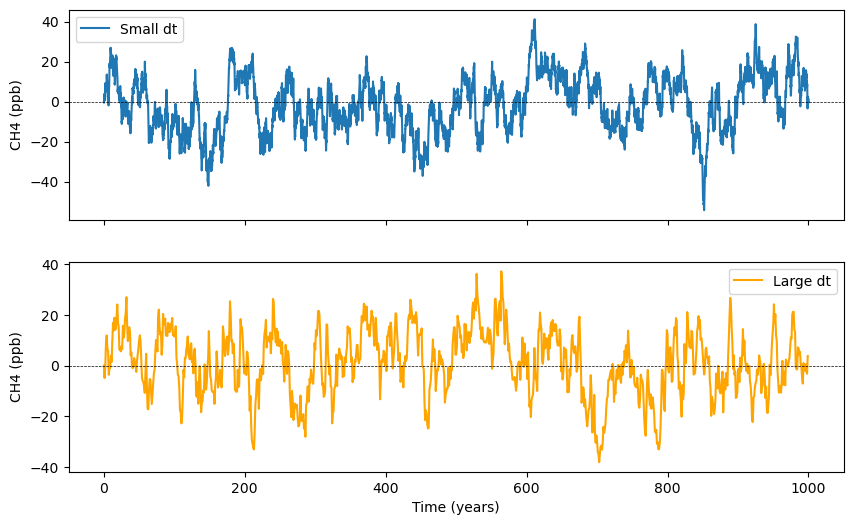

In [6]:
# show one ensemble member of ch4 from each time step
idx_ens = 1
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(np.arange(N_small) * dt_small, ch4_small_ens[idx_ens], label="Small dt")
axs[0].set_ylabel("CH4 (ppb)")
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axs[0].legend()

axs[1].plot(np.arange(N_large) * dt_large, ch4_large_ens[idx_ens], label="Large dt", color='orange')
axs[1].set_xlabel("Time (years)")
axs[1].set_ylabel("CH4 (ppb)")
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axs[1].legend()

In [7]:
# calculate Lomb-Scargle periodograms
# storage for power, append
power_small = []
power_large = []

# iterate over ensemble members
for idx_ens in range(n_ens):
    freqs_small, power_small_indv = LombScargle(
        np.arange(N_small) * dt_small,
        ch4_small_ens[idx_ens],
        ).autopower(
            maximum_frequency=0.5 / dt_small,
            samples_per_peak=5,
            normalization="psd",
        )

    freqs_large, power_large_indv = LombScargle(
        np.arange(N_large) * dt_large,
        ch4_large_ens[idx_ens],
        ).autopower(
            maximum_frequency=0.5 / dt_large,
            samples_per_peak=5,
            normalization="psd",
        )
    
    power_small.append(power_small_indv)
    power_large.append(power_large_indv)

# convert to numpy arrays
power_small = np.array(power_small)
power_large = np.array(power_large)

In [8]:
# calculate integral of the power spectrum
var_empirical_small = np.trapezoid(power_small, x=freqs_small, axis=1) * dt_small * 2 # from Parseval's theorem
var_empirical_large = np.trapezoid(power_large, x=freqs_large, axis=1) * dt_large * 2
print(f"Small dt integral: {var_empirical_small.mean():.2f} ± {var_empirical_small.std(ddof=1):.2f}")
print(f"Large dt integral: {var_empirical_large.mean():.2f} ± {var_empirical_large.std(ddof=1):.2f}")

Small dt integral: 201.67 ± 31.63
Large dt integral: 177.56 ± 15.51


Text(0, 0.5, 'Spectral Density [ppb^2 year]')

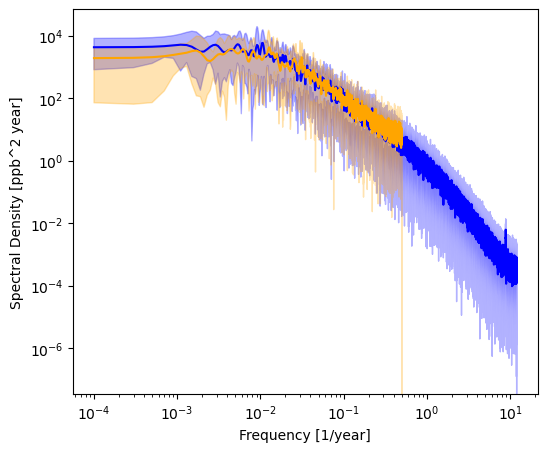

In [9]:
# plot spectral density
# calculate 2.5 and 97.5 percentiles of the ensemble
power_small_ens = np.percentile(power_small, [2.5, 97.5], axis=0) * dt_small # standardize by number of data points
power_large_ens = np.percentile(power_large, [2.5, 97.5], axis=0) * dt_large
power_small_mean = power_small.mean(axis=0) * dt_small
power_large_mean = power_large.mean(axis=0) * dt_large

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(
    freqs_small,
    power_small_mean,
    label="Small dt mean",
    color="blue",
)
ax.fill_between(
    freqs_small,
    power_small_ens[0],
    power_small_ens[1],
    color="blue",
    alpha=0.3,
    label="Small dt 95% CI",
)

ax.loglog(
    freqs_large,
    power_large_mean,
    label="Large dt mean",
    color="orange",
)
ax.fill_between(
    freqs_large,
    power_large_ens[0],
    power_large_ens[1],
    color="orange",
    alpha=0.3,
    label="Large dt 95% CI",
)

ax.set_xlabel("Frequency [1/year]")
ax.set_ylabel("Spectral Density [ppb^2 year]")

If `astropy.LombScargle.autopower()` is normalized by the time step `dt`, then the spectral density should match between the two time-stepping methods (which it does). The fact that a large time step of 1 year is able to integrate a timescale of 0.1 years is a good sign that the noise properties are preserved with large time steps. Below, I will test this by convolving the noise with a firn air filter and checking the properties of the smoothed noise.

## smooth noise and check properties

In [10]:
## firn filter parameters
mode = 25  # years
fwhm = 22  # years
skew = 0.65

firn_filter = FirnFilter.fit_gamma(mode=mode, fwhm=fwhm, skew=skew, dt=0.5)

# convolve firn filter to each ensemble member
ch4_small_smooth_ens = []
ch4_large_smooth_ens = []
for idx_ens in range(n_ens):
    ch4_small_smooth_ens.append(
        firn_filter.apply(series=ch4_small_ens[idx_ens], dt_series=dt_small)
    )
    ch4_large_smooth_ens.append(
        firn_filter.apply(series=ch4_large_ens[idx_ens], dt_series=dt_large)
    )

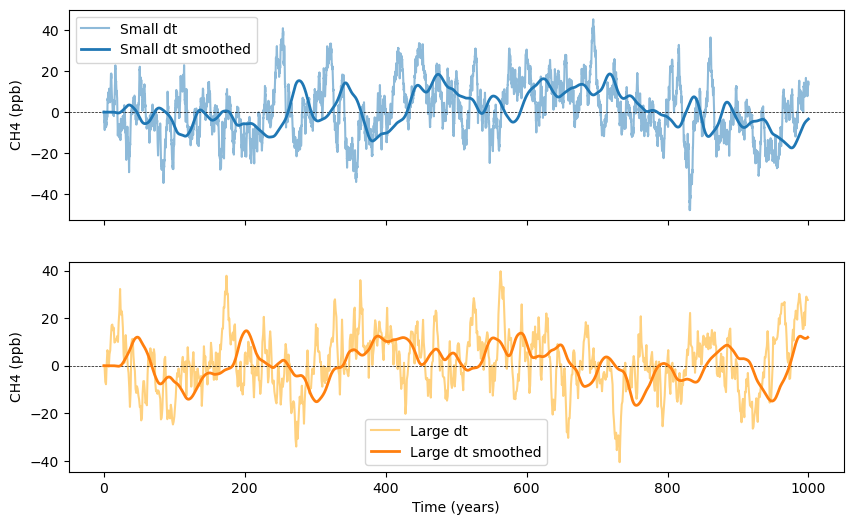

In [11]:
# show one ensemble member of ch4 from each time step
idx_ens = 3
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(np.arange(N_small) * dt_small, ch4_small_ens[idx_ens], label="Small dt", alpha=0.5)
axs[0].set_ylabel("CH4 (ppb)")
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axs[0].plot(np.arange(N_small) * dt_small, ch4_small_smooth_ens[idx_ens], label="Small dt smoothed", color='tab:blue', linewidth=2)
axs[0].legend()

axs[1].plot(np.arange(N_large) * dt_large, ch4_large_ens[idx_ens], label="Large dt", color='orange', alpha=0.5)
axs[1].set_xlabel("Time (years)")
axs[1].set_ylabel("CH4 (ppb)")
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axs[1].plot(np.arange(N_large) * dt_large, ch4_large_smooth_ens[idx_ens], label="Large dt smoothed", color='tab:orange', linewidth=2)
axs[1].legend()

In [12]:
## calculate Lomb-Scargle periodograms for smoothed data
# storage for power, append
power_small_smooth = []
power_large_smooth = []

# iterate over ensemble members
for idx_ens in range(n_ens):
    freqs_small, power_small_smooth_indv = LombScargle(
        np.arange(N_small) * dt_small,
        ch4_small_smooth_ens[idx_ens],
        ).autopower(
            maximum_frequency=0.5 / dt_small,
            samples_per_peak=5,
            normalization="psd",
        )

    freqs_large, power_large_smooth_indv = LombScargle(
        np.arange(N_large) * dt_large,
        ch4_large_smooth_ens[idx_ens],
        ).autopower(
            maximum_frequency=0.5 / dt_large,
            samples_per_peak=5,
            normalization="psd",
        )
    
    power_small_smooth.append(power_small_smooth_indv)
    power_large_smooth.append(power_large_smooth_indv)

# convert to numpy arrays
power_small_smooth = np.array(power_small_smooth)
power_large_smooth = np.array(power_large_smooth)

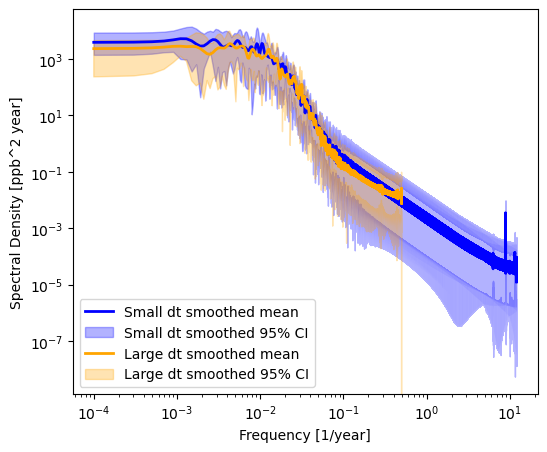

In [13]:
## plot spectral density for smoothed data
# calculate 2.5 and 97.5 percentiles of the ensemble
power_small_smooth_ens = np.percentile(power_small_smooth, [2.5, 97.5], axis=0) * dt_small
power_large_smooth_ens = np.percentile(power_large_smooth, [2.5, 97.5], axis=0) * dt_large
power_small_smooth_mean = power_small_smooth.mean(axis=0) * dt_small
power_large_smooth_mean = power_large_smooth.mean(axis=0) * dt_large

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(
    freqs_small,
    power_small_smooth_mean,
    label="Small dt smoothed mean",
    color="blue",
    linewidth=2,
)
ax.fill_between(
    freqs_small,
    power_small_smooth_ens[0],
    power_small_smooth_ens[1],
    color="blue",
    alpha=0.3,
    label="Small dt smoothed 95% CI",
)
ax.loglog(
    freqs_large,
    power_large_smooth_mean,
    label="Large dt smoothed mean",
    color="orange",
    linewidth=2,
)
ax.fill_between(
    freqs_large,
    power_large_smooth_ens[0],
    power_large_smooth_ens[1],
    color="orange",
    alpha=0.3,
    label="Large dt smoothed 95% CI",
)
ax.set_xlabel("Frequency [1/year]")
ax.set_ylabel("Spectral Density [ppb^2 year]")
ax.legend()

Spectral density of the smoothed noise does match between the two methods, confirming that the noise properties are preserved even with a large time step.